# Notebook 05 — Static Fair-Value Estimation

## Objective

Estimate a static conditional fair-value model for balancing spreads
using operational market-state variables.

The notebook investigates whether:

- balancing spreads remain close to conditional equilibrium,
or whether:

- persistent dislocations emerge through time.

The notebook intentionally uses a static training window
to test whether apparent disequilibrium may arise when
market equilibrium evolves faster than the model adapts.

Primary outputs:

- static XGBoost fair-value model,
- spread residual diagnostics,
- and residual clustering analysis.

## Motivation

Previous notebooks demonstrated that balancing spreads exhibit:

- persistence,
- volatility clustering,
- and identifiable stress regimes.

This raises an important question:

- Can balancing spreads be explained as a stable conditional equilibrium?

To investigate this, an XGBoost regression model is used to estimate
the expected balancing spread conditioned on observed market state.

Residuals from this model are interpreted as:

- deviations from estimated equilibrium,
rather than:

- directly tradable inefficiencies.

Importantly, this notebook intentionally assumes:

- a static equilibrium relationship

which is later challenged in Notebook 06 using walk-forward retraining.

## 1. Load Continuous Market-State Dataset

The continuous market-state dataset constructed in Notebook 04
provides the operational state-space used for fair-value estimation.

In [1]:
import pandas as pd
import numpy as np

# =========================================================
# LOAD DATASET
# =========================================================

market = pd.read_parquet(

    "../data/processed/continuous_market_state.parquet"
)

print(market.shape)

print(market.columns)

(17525, 33)
Index(['timestamp', 'date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key',
       'wind_mw', 'system_price', 'bm_bid_price_vwap', 'basis_spread',
       'total_bid_mw', 'total_offer_mw', 'total_action_mw', 'net_action_mw',
       'action_count', 'total_action_value', 'bm_price_vwap',
       'relative_spread', 'spread_lag_1', 'spread_lag_48',
       'spread_rolling_mean_4', 'spread_volatility_12', 'wind_ramp_4',
       'wind_regime', 'stress', 'future_stress', 'wind_ramp_1',
       'demand_ramp_1', 'demand_ramp_4', 'spread_volatility_4',
       'basis_spread_clipped', 'basis_spread_filtered', 'spread_smooth_24'],
      dtype='object')


## 2. Define Modelling Target

The clipped basis spread is used as the modelling target.

Extreme spread events are clipped to reduce the influence
of rare operational outliers on regression stability.

This improves interpretability of conditional fair-value estimation
while preserving the broader spread-regime structure.

In [2]:
target = 'basis_spread_clipped'

## 3. Define Feature Set

Features include:
- operational balancing activity,
- lagged spread behaviour,
- volatility measures,
- renewable ramps,
- and demand ramps.

These variables are intended to capture:
- system stress,
- operational persistence,
- and evolving balancing conditions.

In [3]:
features = [

    'wind_mw',
    'sw_demand_mw',

    'total_action_mw',
    'action_count',

    'spread_lag_1',
    'spread_lag_48',

    'spread_rolling_mean_4',
    'spread_volatility_4',
    'spread_volatility_12',

    'wind_ramp_1',
    'wind_ramp_4',

    'demand_ramp_1',
    'demand_ramp_4'
]

## 4. Methodological Caveat

Several operational balancing variables are contemporaneous
with the settlement-period spread itself.

For example:
- balancing action volume,
- balancing action count,
- and balancing VWAP construction

partially describe the same operational state used to form
the observed balancing spread.

As a result:
- strong model performance does not necessarily imply
  forward-looking predictive power,
and may instead reflect:
- decomposition of the current operational state.

This notebook therefore interprets the model primarily as:
- a conditional equilibrium estimation framework,
rather than:
- a deployable forecasting system.

In [4]:
model_df = market[
    features + [target]
].dropna()

print(model_df.shape)

(17415, 14)


## 5 — XGBoost fair-value estimation

### 5.1 Import libraries

In [5]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)



### 5.2 Time-ordered split

In [6]:
split = int(len(model_df) * 0.8)

train = model_df.iloc[:split]

test = model_df.iloc[split:]

X_train = train[features]

X_test = test[features]

y_train = train[target]

y_test = test[target]

### 5.3 Train XGBoost model

In [7]:
xgb = XGBRegressor(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(

    X_train,

    y_train
)

print("Model training complete.")

Model training complete.


### 5.4 Generate fair-value predictions

In [8]:
preds = xgb.predict(X_test)

### 5.5 Evaluate performance

### Important Interpretation Note

Several explanatory variables partially encode contemporaneous
balancing conditions within the same settlement period.

As a result, extremely high in-sample fit statistics should not be
interpreted as evidence of deployable forecasting power.

The model is instead interpreted primarily as:
- a conditional equilibrium estimation framework,
rather than:
- a forward-looking trading model.

In [9]:
mae = mean_absolute_error(

    y_test,

    preds
)

r2 = r2_score(

    y_test,

    preds
)

print(f"MAE: {mae:.2f}")

print(f"R²: {r2:.3f}")

MAE: 1.39
R²: 0.995


In [10]:
results = pd.DataFrame({

    'timestamp': market.loc[
        X_test.index,
        'timestamp'
    ].values,

    'actual_spread': y_test.values,

    'predicted_spread': preds

})

results['spread_residual'] = (

    results['actual_spread']
    - results['predicted_spread']
)

results = results.sort_values(
    'timestamp'
)

In [11]:
from pathlib import Path

Path("data/processed").mkdir(
    parents=True,
    exist_ok=True
)

results.to_parquet(
    "../data/processed/static_fair_value_results.parquet"
)

print("Static fair-value results saved.")

Static fair-value results saved.


### 5.6 Build fair-value dataframe

In [12]:
results = test.copy()

results['predicted_fair_value'] = preds

results['spread_residual'] = (

    results[target]

    - results['predicted_fair_value']
)

### 5.7 Plot actual vs fair value

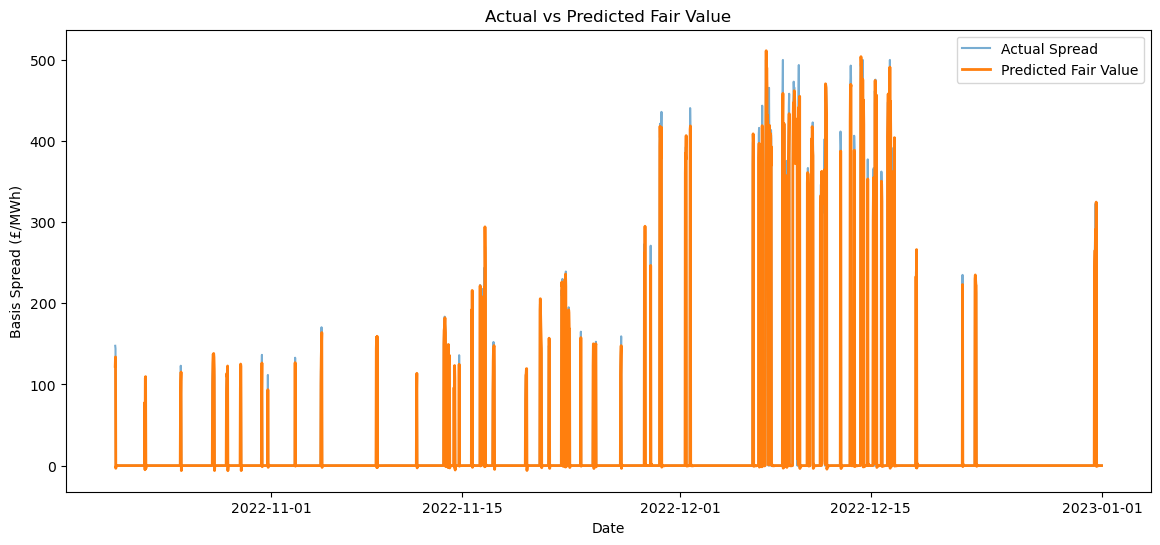

In [13]:
plt.figure(figsize=(14,6))

plt.plot(

    market.loc[results.index, 'timestamp'],

    results[target],

    alpha=0.6,

    label='Actual Spread'
)

plt.plot(

    market.loc[results.index, 'timestamp'],

    results['predicted_fair_value'],

    linewidth=2,

    label='Predicted Fair Value'
)

plt.title(
    "Actual vs Predicted Fair Value"
)

plt.xlabel("Date")

plt.ylabel("Basis Spread (£/MWh)")

plt.legend()

plt.show()

### 5.8 Plot residuals

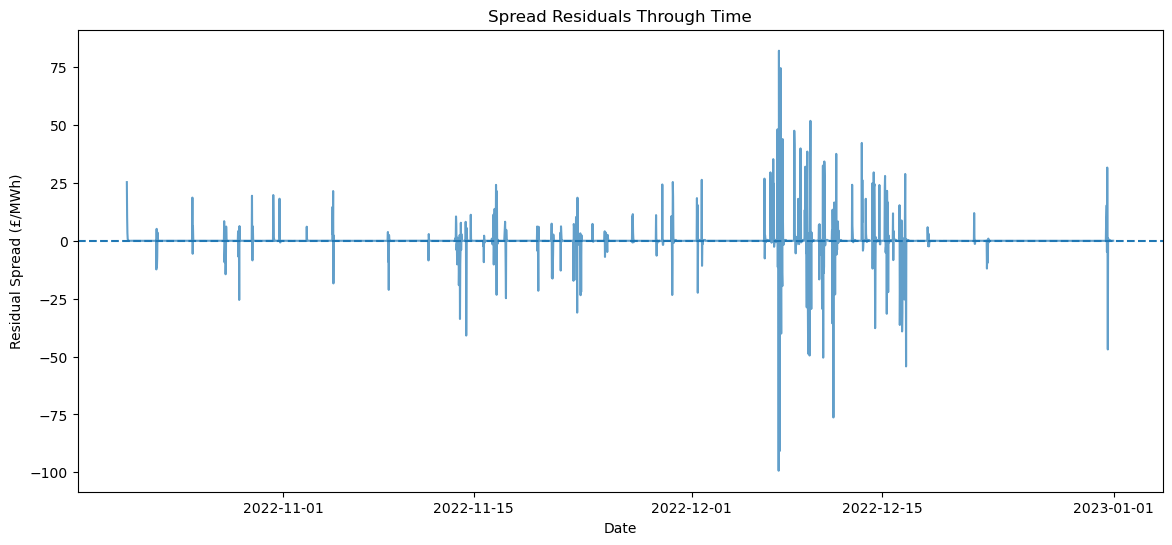

In [14]:
plt.figure(figsize=(14,6))

plt.plot(

    market.loc[results.index, 'timestamp'],

    results['spread_residual'],

    alpha=0.7
)

plt.axhline(

    0,

    linestyle='--'
)

plt.title(
    "Spread Residuals Through Time"
)

plt.xlabel("Date")

plt.ylabel("Residual Spread (£/MWh)")

plt.show()

### 5.9 Feature importance

In [15]:
importance = pd.Series(

    xgb.feature_importances_,

    index=features

).sort_values(ascending=False)

print(importance)

total_action_mw          0.565018
action_count             0.265887
spread_volatility_12     0.077327
spread_lag_1             0.029415
spread_volatility_4      0.026541
spread_rolling_mean_4    0.018643
spread_lag_48            0.006792
wind_mw                  0.003151
demand_ramp_4            0.002335
demand_ramp_1            0.002152
wind_ramp_4              0.001049
wind_ramp_1              0.000967
sw_demand_mw             0.000723
dtype: float32


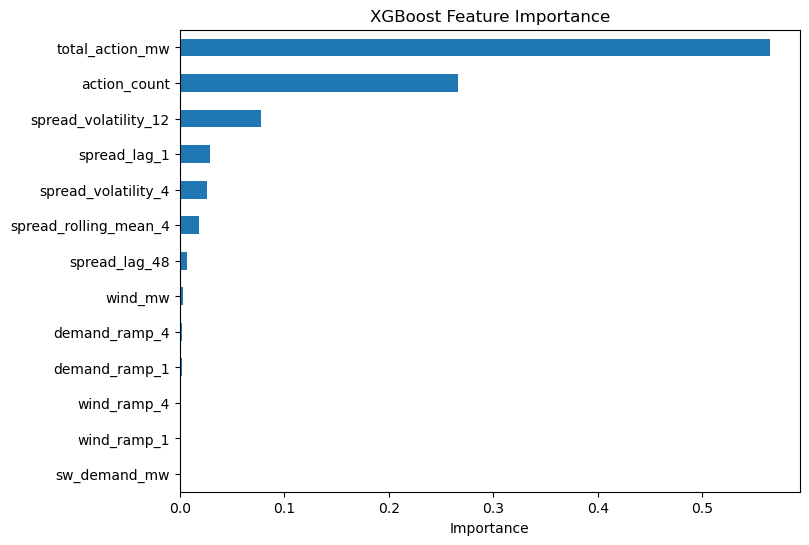

In [16]:
importance.sort_values().plot(

    kind='barh',

    figsize=(8,6)
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel("Importance")

plt.show()

Residuals through time

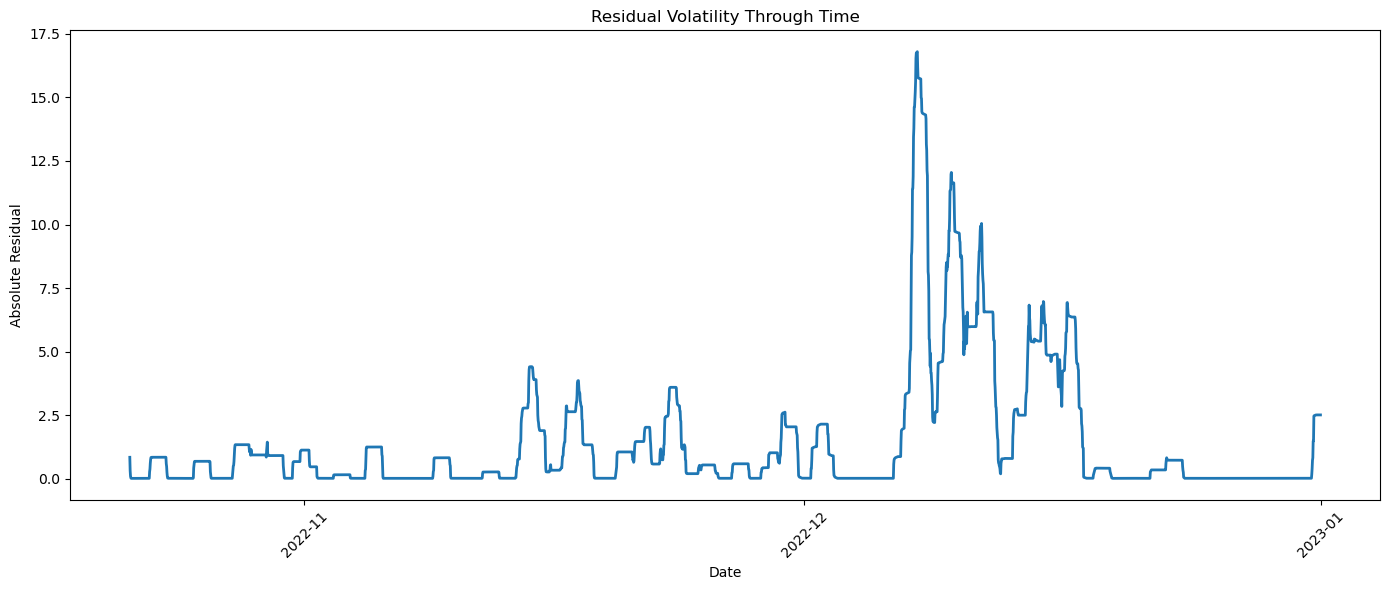

In [17]:
results['residual_abs'] = (
    results['spread_residual'].abs()
)

results['residual_abs_rolling'] = (

    results['residual_abs']
    .rolling(48)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(

    market.loc[results.index, 'timestamp'],

    results['residual_abs_rolling'],

    linewidth=2
)

# =========================================================
# DATE FORMATTING
# =========================================================

import matplotlib.dates as mdates

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

# =========================================================
# LABELS
# =========================================================

plt.title(
    "Residual Volatility Through Time"
)

plt.xlabel("Date")

plt.ylabel("Absolute Residual")

plt.tight_layout()

plt.show()

## 6 — Residual Regime Analysis

**Large positive residuals**

In [18]:
results['positive_dislocation'] = (

    results['spread_residual']
    > 50
)

### Negative Residual Events

Negative residual dislocations were substantially less frequent
than positive residual regimes.

This asymmetry suggests that upward spread deviations and stress
expansion periods dominate the residual structure identified by
the static equilibrium framework.

In [19]:
results['negative_dislocation'] = (

    results['spread_residual']
    < -50
)

In [20]:
print(

    results[
        [
            'positive_dislocation',
            'negative_dislocation'
        ]
    ].mean()
)

positive_dislocation    0.000861
negative_dislocation    0.001436
dtype: float64


Dislocation clustering

In [21]:
results['positive_cluster'] = (

    results['positive_dislocation']
    .rolling(4)
    .mean()
)

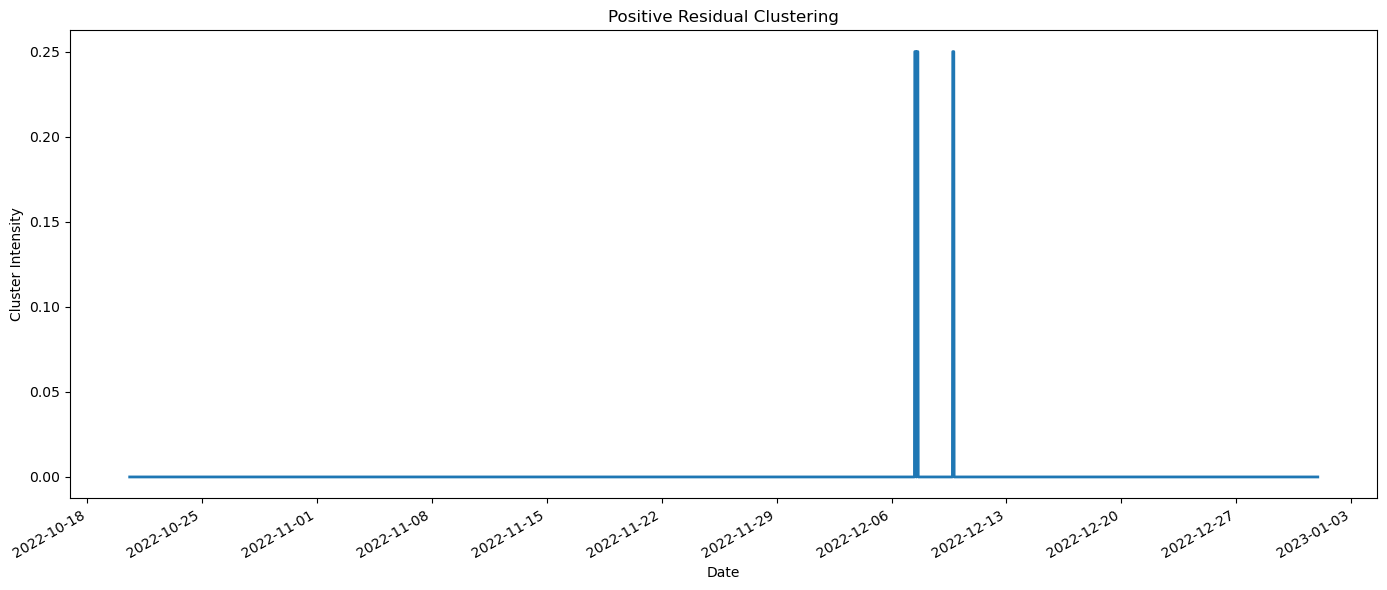

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(

    market.loc[results.index, 'timestamp'],

    results['positive_cluster'],

    linewidth=2
)

# =========================================================
# MORE DETAILED DATE TICKS
# =========================================================

ax.xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

fig.autofmt_xdate()

# =========================================================
# LABELS
# =========================================================

ax.set_title(
    "Positive Residual Clustering"
)

ax.set_xlabel("Date")

ax.set_ylabel("Cluster Intensity")

plt.tight_layout()

plt.show()

In [23]:
results.groupby(
    pd.qcut(
        market.loc[results.index, 'wind_mw'],
        4
    )
)['spread_residual'].mean()

/tmp/ipykernel_2595/2176801267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby(


wind_mw
(443.999, 6406.426]      0.173872
(6406.426, 9145.467]     0.363605
(9145.467, 12802.471]   -0.035590
(12802.471, 18620.0]     0.002895
Name: spread_residual, dtype: float64

## 7 — Conclusions

### Market Structure

The Balancing Mechanism spread exhibits strong temporal structure,
including autocorrelation, volatility clustering, and identifiable
stress regimes.

Spread behaviour appears highly state-dependent rather than random,
with operational balancing activity emerging as the dominant explanatory
variable in fair-value estimation.

Fair Value Estimation

An XGBoost model was used to estimate conditional fair value
for balancing spreads based on market-state variables including:

- balancing activity,
- lagged spreads,
- volatility,
- wind generation,
- and demand conditions.

The model successfully captured the majority of spread behaviour,
suggesting the BM generally operates near conditional equilibrium.

### Residual Structure Findings

Residual analysis revealed that large dislocations from estimated
fair value are relatively rare.

However, several concentrated late-year stress episodes produced
persistent residual widening, indicating periods where balancing
conditions deviated materially from learned equilibrium behaviour.

These residual clusters may reflect:
- temporary flexibility scarcity,
- rapidly evolving operational conditions,
- or instability in the assumed static equilibrium relationship.

Interestingly, residual expansion was not largest during the
highest wind regimes, but instead peaked during moderate wind
conditions.

This may suggest that intermediate renewable-output conditions
produce more unstable redispatch dynamics than fully saturated
high-wind regimes.

### Wind & Flexibility Interpretation

Balancing spreads compress materially during high-wind conditions,
while moderate-wind regimes exhibited the largest average residuals
from estimated fair value.

This suggests flexibility scarcity may emerge most strongly during
intermediate system conditions rather than extreme renewable scarcity.

### Interpretation

The static fair-value framework appears to identify periods
where observed spreads diverge from historically learned
market-state relationships.

However, it remains unclear whether these residual regimes reflect:
- genuine persistent disequilibrium,
or:
- evolving equilibrium conditions not captured by a static model.

This question motivates the adaptive walk-forward framework
developed in Notebook 06.

### Limitations

The current framework estimates fair value using a static
training window and does not account for evolving market equilibrium.

Residual widening during late-year stress periods may therefore reflect:
- genuine disequilibrium,
- structural market evolution,
- or model drift.

### Next Steps

Future work will extend the framework using walk-forward
equilibrium estimation to distinguish:
- adaptive market repricing,
- from persistent structural dislocation.

Additional future extensions may include:
- locational constraint analysis,
- battery-duration valuation,
- and flexibility adequacy modelling.

In [24]:
from pathlib import Path

# Attach timestamp before saving
results['timestamp'] = market.loc[results.index, 'timestamp'].values

# Create processed-data directory
Path("data/processed").mkdir(parents=True, exist_ok=True)

# Save static fair-value results *after all columns are created*
results.to_parquet(
    "../data/processed/static_fair_value_results.parquet"
)

print("Static fair-value results saved with full diagnostics.")


Static fair-value results saved with full diagnostics.
